# ESCI exploratory analysis

US locale, small version. Scope and splits come from `configs/base.yaml` and the
files written by `scripts/make_splits.py`, so this notebook describes exactly the
data the experiments use.

Figures are saved to `docs/figures/` for the README.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from esci.config import load_config
from esci.data import eda
from esci.data.corpus import read_corpus
from esci.data.download import DATASET_FILES, DATASET_SUBDIR
from esci.data.splits import filter_examples, read_splits

ROOT = Path.cwd().parent
FIGURES = ROOT / "docs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

cfg = load_config(ROOT / "configs" / "base.yaml")

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": 0.3})


def save(fig, name):
    fig.savefig(FIGURES / f"{name}.png", dpi=120, bbox_inches="tight")


examples_path = cfg.paths.raw_dir / "esci-data" / DATASET_SUBDIR / DATASET_FILES[0]
examples = filter_examples(pd.read_parquet(examples_path), cfg.data.locale, cfg.data.small_version)
splits = read_splits(cfg.paths.processed_dir / "splits")
corpus = read_corpus(cfg.paths.processed_dir)

print(f"{len(examples):,} judgements over {examples.query_id.nunique():,} queries")
print(f"{len(corpus):,} products in the retrieval corpus")

601,354 judgements over 29,844 queries
482,105 products in the retrieval corpus


## Relevance labels
Gains are E 1.0, S 0.1, C 0.01, I 0 (decision D3). The label mix sets how much
headroom NDCG has, and how many examples of each class the re-ranker gets to
learn from.

,name,count,percent
0,Exact,261527,43.49
1,Substitute,211191,35.12
2,Complement,27189,4.52
3,Irrelevant,101447,16.87


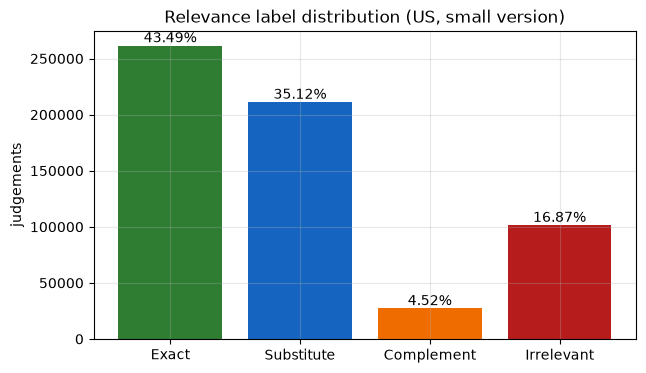

In [2]:
counts = examples.esci_label.value_counts().reindex(list(eda.ESCI_LABELS))
dist = pd.DataFrame(
    {
        "name": [eda.LABEL_NAMES[label] for label in eda.ESCI_LABELS],
        "count": counts.to_numpy(),
        "percent": (100 * counts / counts.sum()).round(2).to_numpy(),
    }
)
display(dist)

fig, ax = plt.subplots()
ax.bar(dist["name"], dist["count"], color=["#2E7D32", "#1565C0", "#EF6C00", "#B71C1C"])
ax.set(ylabel="judgements", title="Relevance label distribution (US, small version)")
for x, (count, pct) in enumerate(zip(dist["count"], dist["percent"], strict=True)):
    ax.text(x, count, f"{pct}%", ha="center", va="bottom")
save(fig, "label_distribution")
plt.show()

## Judged products per query

ESCI judges only a handful of products per query. That is why retrieval against
482k products returns many unjudged items, which decision D8 scores as gain 0
and reports as a lower bound.

,judged,exact
count,29844.00,29844.00
mean,20.15,8.76
min,8.00,0.00
p25,16.00,4.00
p50,16.00,7.00
p90,40.00,16.00
p99,43.00,33.00
max,188.00,81.00


queries with no exact product: 1


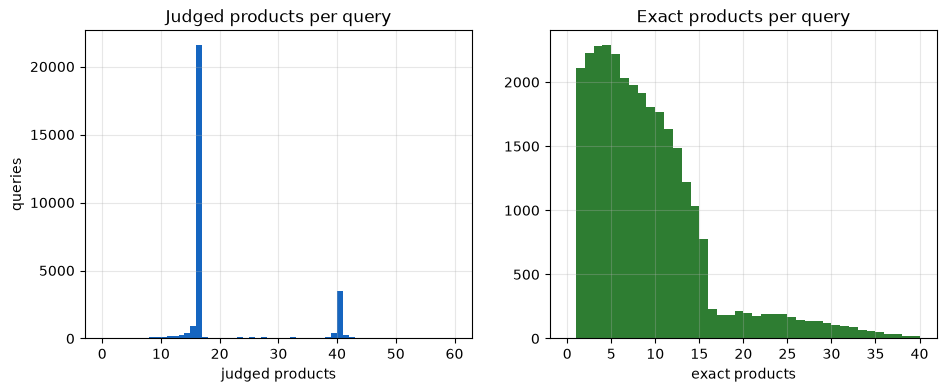

In [3]:
judged = examples.groupby("query_id").size()
exact = eda.exact_per_query(examples)

display(pd.DataFrame({"judged": eda.describe_series(judged), "exact": eda.describe_series(exact)}))
print("queries with no exact product:", int((exact == 0).sum()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(judged, bins=range(0, 61), color="#1565C0")
axes[0].set(xlabel="judged products", ylabel="queries", title="Judged products per query")
axes[1].hist(exact, bins=range(0, 41), color="#2E7D32")
axes[1].set(xlabel="exact products", title="Exact products per query")
save(fig, "judgements_per_query")
plt.show()

## Query length

Short queries carry little lexical signal, which is where dense retrieval is
expected to help most. Whether it does is research question 1.

count    29844.00
mean         3.89
min          1.00
p25          3.00
p50          4.00
p90          6.00
p99          9.00
max         29.00
dtype: float64

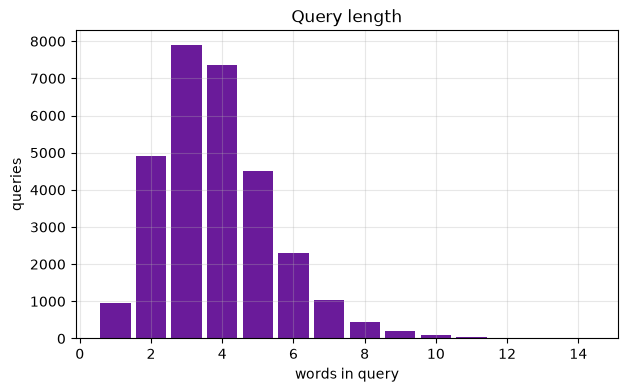

['#15 charm', '$1', '$10 candles', '$5 items', '.7 pens', '00 grease', '1$xrphone cases', '1+ phone', '1-18 coronet', '1-8x scope']


In [4]:
queries = examples.drop_duplicates("query_id")["query"]
words = queries.str.count(r"\S+")
display(eda.describe_series(words))

fig, ax = plt.subplots()
ax.hist(words, bins=range(1, 16), color="#6A1B9A", align="left", rwidth=0.85)
ax.set(xlabel="words in query", ylabel="queries", title="Query length")
save(fig, "query_length")
plt.show()

print(queries[words <= 2].head(10).to_list())

## Splits

Test comes from the dataset's own `split` column. Validation is a random 10% of
train queries at seed 42, grouped by query ID (decision D2).

In [5]:
rows = []
for name, ids in splits.items():
    subset = examples[examples.query_id.isin(ids)]
    share = subset.esci_label.value_counts(normalize=True)
    rows.append(
        {
            "split": name,
            "queries": subset.query_id.nunique(),
            "judgements": len(subset),
            **{f"{label}_%": round(100 * share.get(label, 0), 1) for label in eda.ESCI_LABELS},
        }
    )
display(pd.DataFrame(rows))

,split,queries,judgements,E_%,S_%,C_%,I_%
0,train,18799,377719,43.3,35.2,4.6,16.9
1,val,2089,41934,43.1,35.2,4.5,17.2
2,test,8956,181701,43.9,35.0,4.5,16.7


## Query overlap between splits

No query ID spans two splits. The same wording can still appear under different
IDs, which would let a model memorise a query seen in training and then be scored
on it at test time.

In [6]:
display(eda.duplicate_queries_across_splits(examples, splits))

,metric,value
0,unique query strings,29844.0
1,strings in more than one split,0.0
2,percent,0.0


## Corpus text

Product text is title, brand, colour and bullets in that order, truncated at 256
tokens for the bi-encoder (decision D10). BM25 indexes the full text.

,characters,words
count,482105.00,482105.0
mean,726.56,117.9
min,1.00,1.0
p25,261.00,42.0
p50,610.00,98.0
p90,1503.00,245.0
p99,2306.00,375.0
max,2771.00,549.0


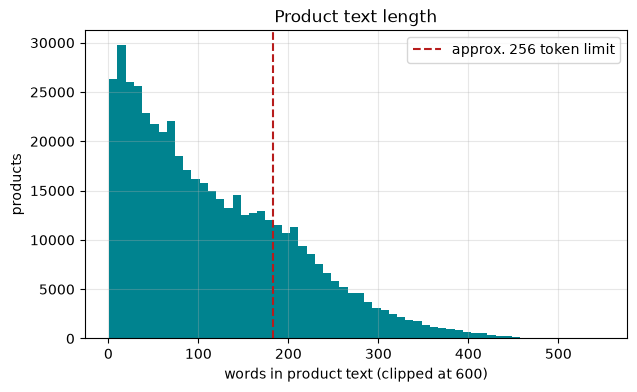

,products,percent
product_brand,,
Nike,2818,0.58
adidas,1841,0.38
Amazon Essentials,1556,0.32
Hanes,1352,0.28
Under Armour,1309,0.27
Disney,1270,0.26
Amazon Basics,1054,0.22
Rubie's,916,0.19
Skechers,817,0.17


products with no brand: 27191


In [7]:
chars = corpus.product_text.str.len()
text_words = corpus.product_text.str.count(r"\S+")
summary = {"characters": eda.describe_series(chars), "words": eda.describe_series(text_words)}
display(pd.DataFrame(summary))

fig, ax = plt.subplots()
ax.hist(text_words.clip(upper=600), bins=60, color="#00838F")
ax.axvline(256 / 1.4, color="#B71C1C", linestyle="--", label="approx. 256 token limit")
ax.set(xlabel="words in product text (clipped at 600)", ylabel="products")
ax.set_title("Product text length")
ax.legend()
save(fig, "product_text_length")
plt.show()

brands = corpus.product_brand.fillna("").str.strip()
top = brands[brands != ""].value_counts().head(15)
display(pd.DataFrame({"products": top, "percent": (100 * top / len(corpus)).round(2)}))
print("products with no brand:", int((brands == "").sum()))

## Takeaways

Write these up from the output above: label balance, judged products per query,
query length, how many products truncation affects, and the query overlap figure.
Anything surprising here needs explaining in the README.